<a href="https://colab.research.google.com/github/shreenathsherkar71-sys/MESA-Stellar-Evolution-Simulations/blob/main/MESA_Stellar_Evolution_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MESA Stellar Evolution Study

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import csv
!pip install mesa_reader
!pip install mesa_reader ipympl
import mesa_reader as mr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.1 MB/s eta 0:00:00


## Model Resolution and Time Scales (1$M_⊙$ Star)


####Stellar Properties

In [ ]:
h = mr.MesaData("SimData/history.data")

# Initial hydrogen abundance
X0 = h.center_h1[0]

# Approximate ZAMS:
# when central hydrogen first changes noticeably
zams = np.argmax(h.center_h1 < X0 - 1e-3)

# Approximate TAMS:
# when central hydrogen is essentially exhausted
tams = np.argmax(h.center_h1 < 1e-3)

# End of simulation
end = len(h.star_age)-1

print(zams, tams, end)

AttributeError: 'function' object has no attribute 'bulk_names_line'

<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_11150/1200419199.py:7: SyntaxWarning: invalid escape sequence '\o'
  fig.suptitle('Evolution of Stellar Properties of $1M_\odot$ star', fontsize=16, y=0.92)


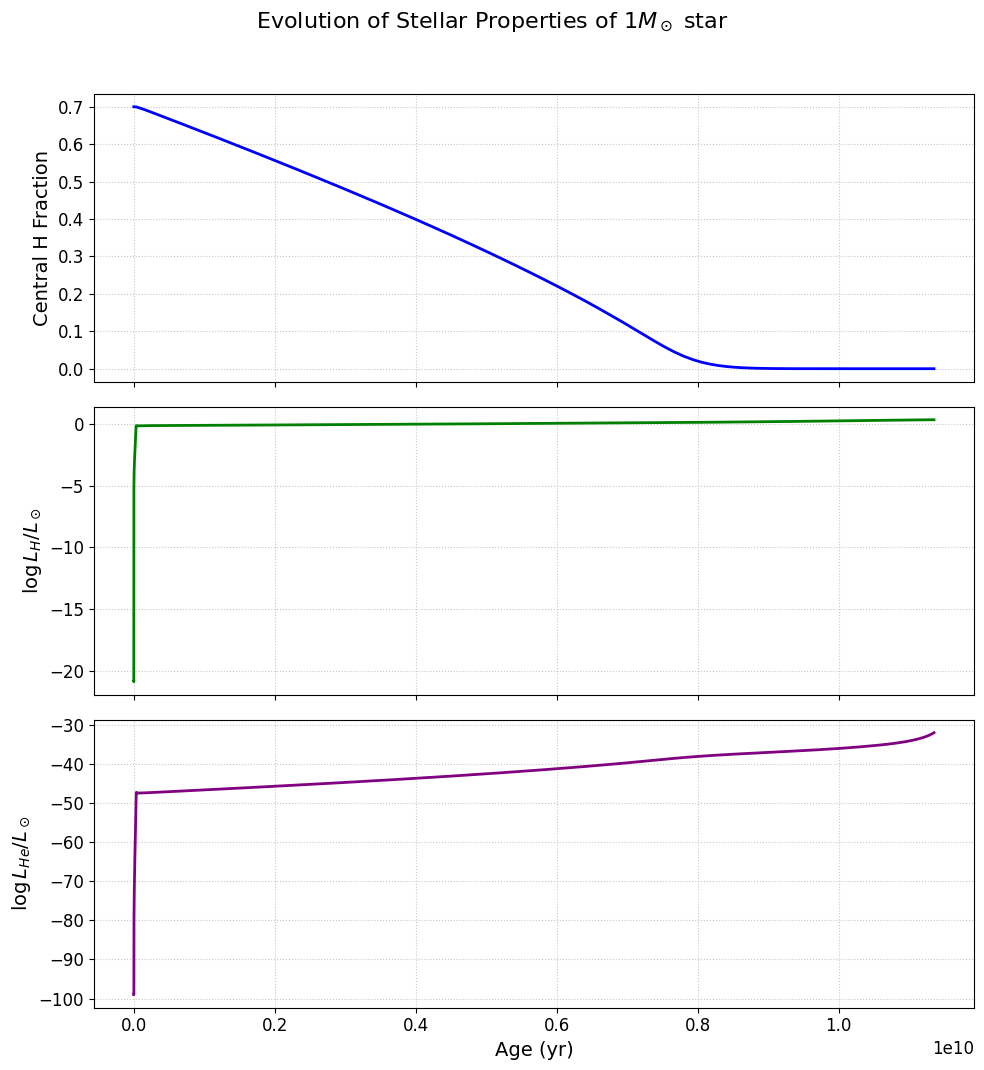

In [ ]:
h = mr.MesaData("SimData/history.data")

plt.rcParams.update({'font.size': 12})

fig, ax = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

fig.suptitle('Evolution of Stellar Properties of $1M_\odot$ star', fontsize=16, y=0.92)

ax[0].plot(h.star_age, h.center_h1, lw=2, color='blue')
ax[0].set_ylabel("Central H Fraction", fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.7)

ax[1].plot(h.star_age, h.log_LH, lw=2, color='green')
ax[1].set_ylabel(r"$\log L_H / L_\odot$", fontsize=14)
ax[1].grid(True, linestyle=':', alpha=0.7)

ax[2].plot(h.star_age, h.log_LHe, lw=2, color='purple')
ax[2].set_ylabel(r"$\log L_{He} / L_\odot$", fontsize=14)
ax[2].set_xlabel("Age (yr)", fontsize=14)
ax[2].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

####HR Track with phase identification

ZAMS = 760
TAMS = 832
Shell = 838

ZAMS Age = 38553060.54412752
TAMS Age = 8907561628.099676
Shell Age = 9181898024.112112
----------------------------------------------------------------------------------------------------
Lnuc/L at ZAMS = 0.9994164601060797
Center H at ZAMS = 0.6994778343306778
Center H at TAMS = 0.0008553372213047455
He Core Mass at Shell = 0.01025259314189736
log LHe = -36.86049275019371


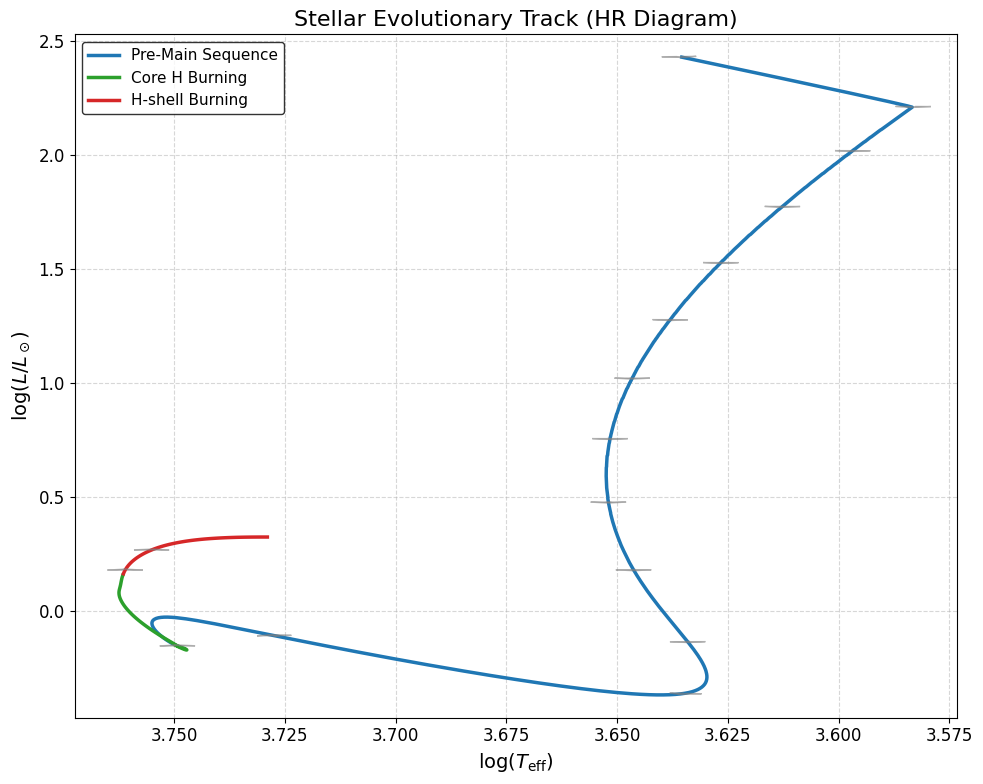

In [ ]:
h = mr.MesaData("SimData/history.data")

# Convert logarithmic luminosities
Lnuc = 10**h.log_Lnuc
L = 10**h.log_L

ratio = Lnuc/L

# ZAMS
zams = np.argmax(ratio >= 0.99)

# TAMS
tams = np.argmax(h.center_h1 < 1e-3)

# H-shell burning
shell = np.argmax(
    (h.center_h1 < 1e-3) &
    (h.he_core_mass > 0.01)
)

print("ZAMS =",zams)
print("TAMS =",tams)
print("Shell =",shell)

print()

print("ZAMS Age =",h.star_age[zams])
print("TAMS Age =",h.star_age[tams])
print("Shell Age =",h.star_age[shell])

print("--"*50)

print("Lnuc/L at ZAMS =",ratio[zams])

print("Center H at ZAMS =",h.center_h1[zams])

print("Center H at TAMS =",h.center_h1[tams])

print("He Core Mass at Shell =",h.he_core_mass[shell])

print("log LHe =",h.log_LHe[shell])


plt.rcParams.update({'font.size': 12})

fig,ax=plt.subplots(figsize=(10,8))

# PMS
ax.plot(
    h.log_Teff[:zams],
    h.log_L[:zams],
    lw=2.5,
    color="#1f77b4",
    label="Pre-Main Sequence"
)

# Core H Burning
ax.plot(
    h.log_Teff[zams:tams],
    h.log_L[zams:tams],
    lw=2.5,
    color="#2ca02c",
    label="Core H Burning"
)

# H-shell Burning
ax.plot(
    h.log_Teff[tams:],
    h.log_L[tams:],
    lw=2.5,
    color="#d62728",
    label="H-shell Burning"
)

ax.invert_xaxis() # Invert x-axis for HR diagram convention

ax.set_xlabel(r'$\log(T_{\rm eff})$',fontsize=14)
ax.set_ylabel(r'$\log(L/L_\odot)$',fontsize=14)

ax.set_title('Stellar Evolutionary Track (HR Diagram)', fontsize=16)

ax.legend(fontsize=11, frameon=True, edgecolor='black')

plt.grid(alpha=0.5, linestyle='--')

# Evolutionary arrows
for i in range(0, len(h.log_Teff) - 1, 60):
    if i + 1 < len(h.log_Teff):
        dx = h.log_Teff[i+1] - h.log_Teff[i]
        dy = h.log_L[i+1] - h.log_L[i]

        ax.arrow(
            h.log_Teff[i],
            h.log_L[i],
            dx,
            dy,
            head_width=0.008,
            head_length=0.004,
            fc='gray',  # Face color
            ec='gray', # Edge color
            length_includes_head=True,
            alpha=0.6,
            zorder=3
        )

ax.set_xlim(h.log_Teff.max() + 0.01, h.log_Teff.min() - 0.01)
ax.set_ylim(h.log_L.min() - 0.1, h.log_L.max() + 0.1)

plt.tight_layout()
plt.show()

####Adaptive Timestep Control

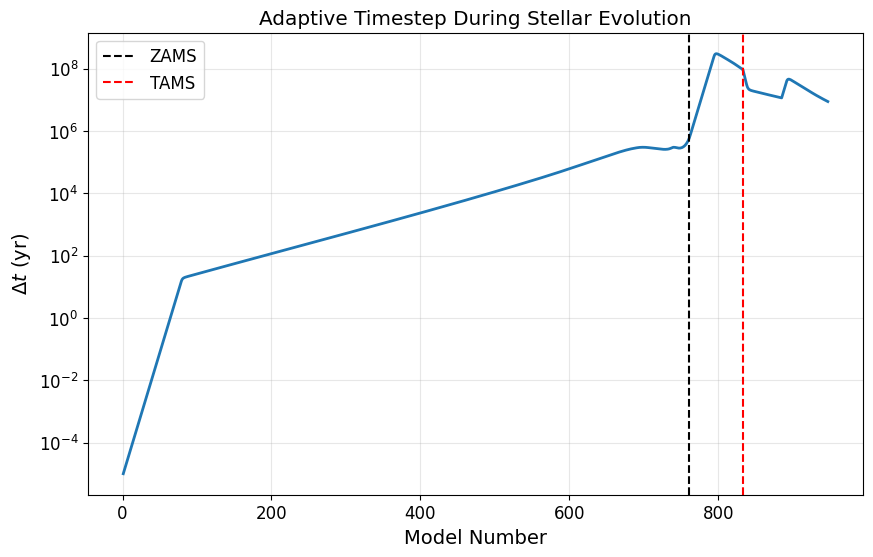

In [ ]:
h = mr.MesaData("SimData/history.data")

dt = 10**h.log_dt

plt.figure(figsize=(10,6))

plt.plot(
    h.model_number,
    dt,
    lw=2
)

plt.xlabel("Model Number",fontsize=14)
plt.ylabel(r'$\Delta t$ (yr)',fontsize=14)

plt.yscale("log")

plt.grid(alpha=0.3)

plt.axvline(
    h.model_number[zams],
    ls='--',
    c='k',
    label="ZAMS"
)

plt.axvline(
    h.model_number[tams],
    ls='--',
    c='red',
    label="TAMS"
)

plt.legend()

plt.title("Adaptive Timestep During Stellar Evolution")

plt.show()

Text(0, 0.5, 'dt (yr)')

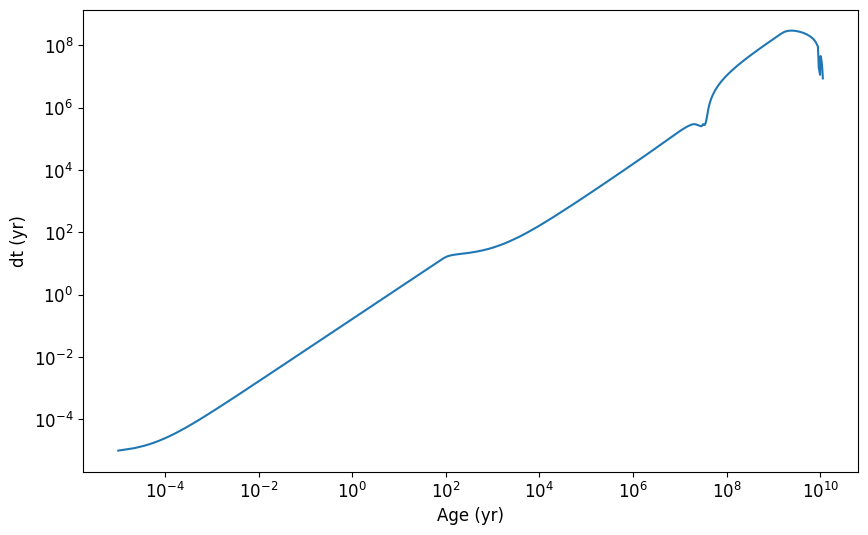

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    h.star_age,
    dt
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Age (yr)")
plt.ylabel("dt (yr)")

In [ ]:
import mesa_reader as mr

p = mr.MesaData("SimData/profile22.data")

print(p.bulk_names)

('zone', 'mass', 'logR', 'logT', 'logRho', 'logP', 'x_mass_fraction_H', 'y_mass_fraction_He', 'z_mass_fraction_metals')


####Mesh Resolution

In [ ]:
p = mr.MesaData("SimData/profile22.data")

m = p.mass

dm = np.abs(np.diff(m))

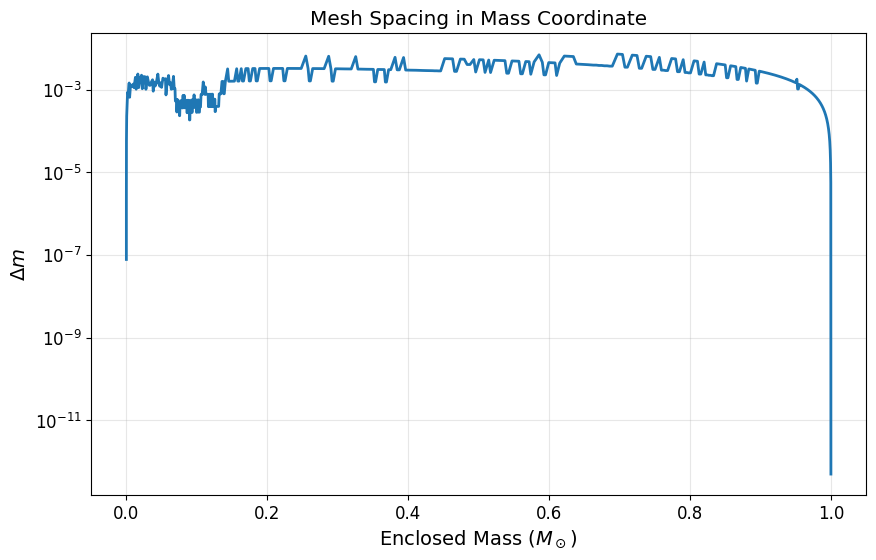

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    m[:-1],
    dm,
    lw=2
)

plt.yscale("log")

plt.xlabel(r"Enclosed Mass ($M_\odot$)",fontsize=14)

plt.ylabel(r"$\Delta m$",fontsize=14)

plt.title("Mesh Spacing in Mass Coordinate")

plt.grid(alpha=0.3)

plt.show()

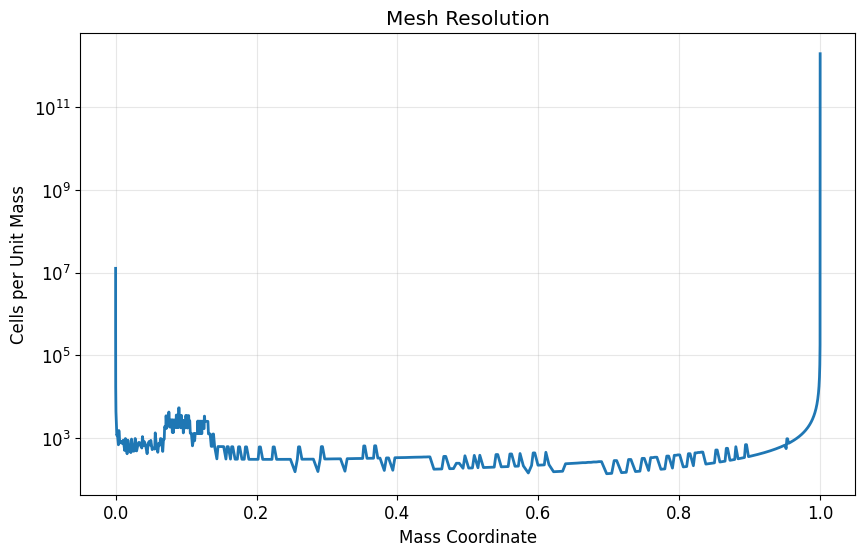

In [ ]:
resolution = 1/dm

plt.figure(figsize=(10,6))

plt.plot(
    m[:-1],
    resolution,
    lw=2
)

plt.yscale("log")

plt.xlabel("Mass Coordinate")

plt.ylabel("Cells per Unit Mass")

plt.grid(alpha=0.3)
plt.title("Mesh Resolution")
plt.show()

####Timescale Evolution

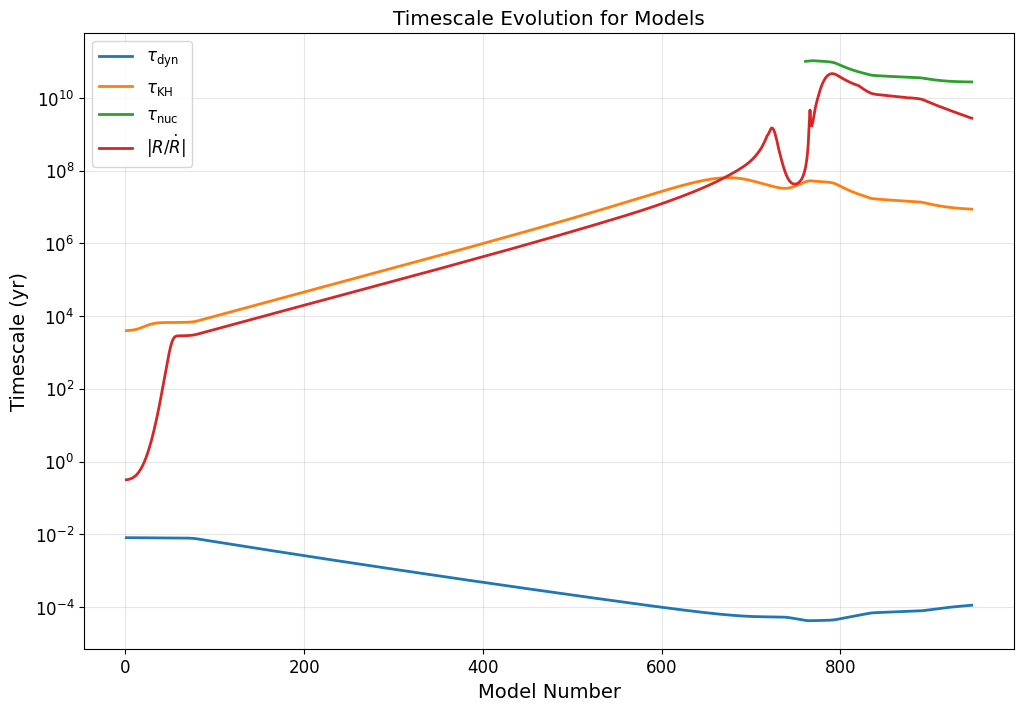

In [ ]:

#Constants of sun for cgs conversion
G = 6.67430e-8
MSUN = 1.98847e33
RSUN = 6.957e10
LSUN = 3.828e33
c = 2.99792458e10
year = 3.154e7

#Conversion
M = h.star_mass * MSUN
R = (10**h.log_R) * RSUN
L = (10**h.log_L) * LSUN
Lnuc = (10**h.log_Lnuc) * LSUN

#dynamic timescale
tau_dyn = np.sqrt(R**3/(G*M))/year

#Thermal timescale
tau_kh = (G*M**2)/(R*L)/year

#Nuclear Timescale (Masked)
ratio = Lnuc / L
tau_nuc = np.full_like(L, np.nan)
mask = ratio > 0.99
tau_nuc[mask] = (
    0.007
    * h.total_mass_h1[mask]
    * MSUN
    * c**2
    / Lnuc[mask]
    / year
)

#Radius change Timescale
dRdt = np.gradient(R) / np.gradient(h.star_age * year)
tau_R = np.abs(R / dRdt) / year
plt.figure(figsize=(12,8))

#Plotting

plt.title("Timescale Evolution for Models")
plt.plot(
    h.model_number,
    tau_dyn,
    label=r'$\tau_{\rm dyn}$',
    lw=2
)

plt.plot(
    h.model_number,
    tau_kh,
    label=r'$\tau_{\rm KH}$',
    lw=2
)

plt.plot(
    h.model_number,
    tau_nuc,
    label=r'$\tau_{\rm nuc}$',
    lw=2
)

plt.plot(
    h.model_number,
    tau_R,
    label=r'$|R/\dot R|$',
    lw=2
)

plt.yscale('log')

plt.xlabel('Model Number',fontsize=14)

plt.ylabel('Timescale (yr)',fontsize=14)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

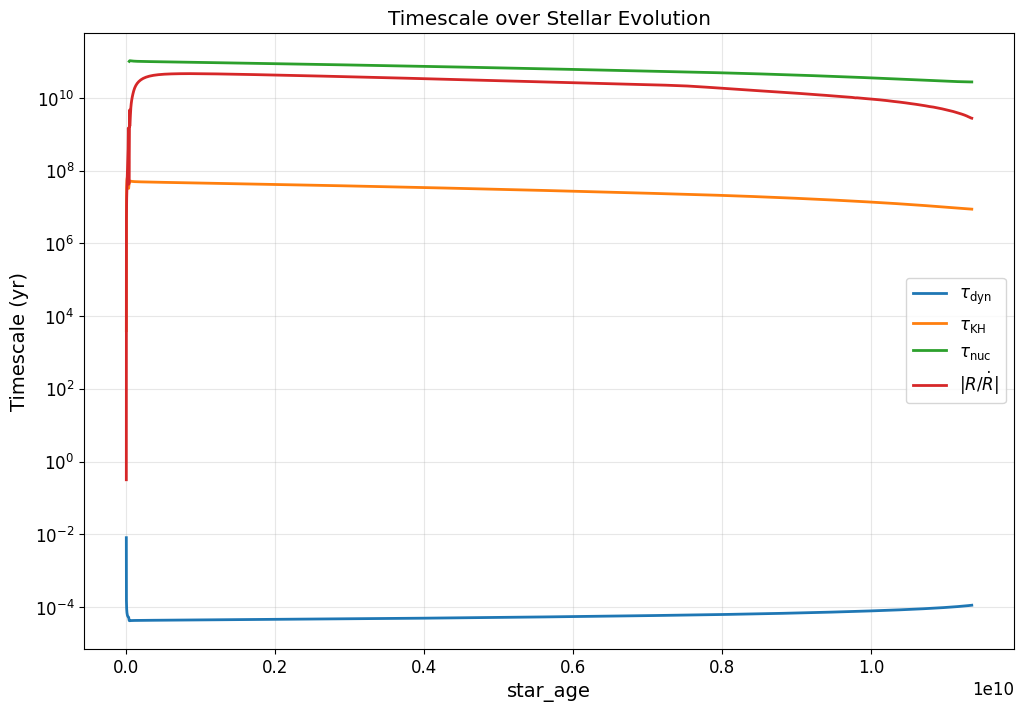

In [ ]:

#Constants of sun for cgs conversion
G = 6.67430e-8
MSUN = 1.98847e33
RSUN = 6.957e10
LSUN = 3.828e33
c = 2.99792458e10
year = 3.154e7

#Conversion
M = h.star_mass * MSUN
R = (10**h.log_R) * RSUN
L = (10**h.log_L) * LSUN
Lnuc = (10**h.log_Lnuc) * LSUN

#dynamic timescale
tau_dyn = np.sqrt(R**3/(G*M))/year

#Thermal timescale
tau_kh = (G*M**2)/(R*L)/year

#Nuclear Timescale^
ratio = Lnuc / L
tau_nuc = np.full_like(L, np.nan)
mask = ratio > 0.99
tau_nuc[mask] = (
    0.007
    * h.total_mass_h1[mask]
    * MSUN
    * c**2
    / Lnuc[mask]
    / year
)

#Radius change Timescale
dRdt = np.gradient(R) / np.gradient(h.star_age * year)
tau_R = np.abs(R / dRdt) / year
plt.figure(figsize=(12,8))

#Plotting
plt.title("Timescale over Stellar Evolution")
plt.plot(
    h.star_age,
    tau_dyn,
    label=r'$\tau_{\rm dyn}$',
    lw=2
)

plt.plot(
    h.star_age,
    tau_kh,
    label=r'$\tau_{\rm KH}$',
    lw=2
)

plt.plot(
    h.star_age,
    tau_nuc,
    label=r'$\tau_{\rm nuc}$',
    lw=2
)

plt.plot(
    h.star_age,
    tau_R,
    label=r'$|R/\dot R|$',
    lw=2
)

plt.yscale('log')

plt.xlabel('star_age',fontsize=14)

plt.ylabel('Timescale (yr)',fontsize=14)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

####Timescale Ratio Evolution

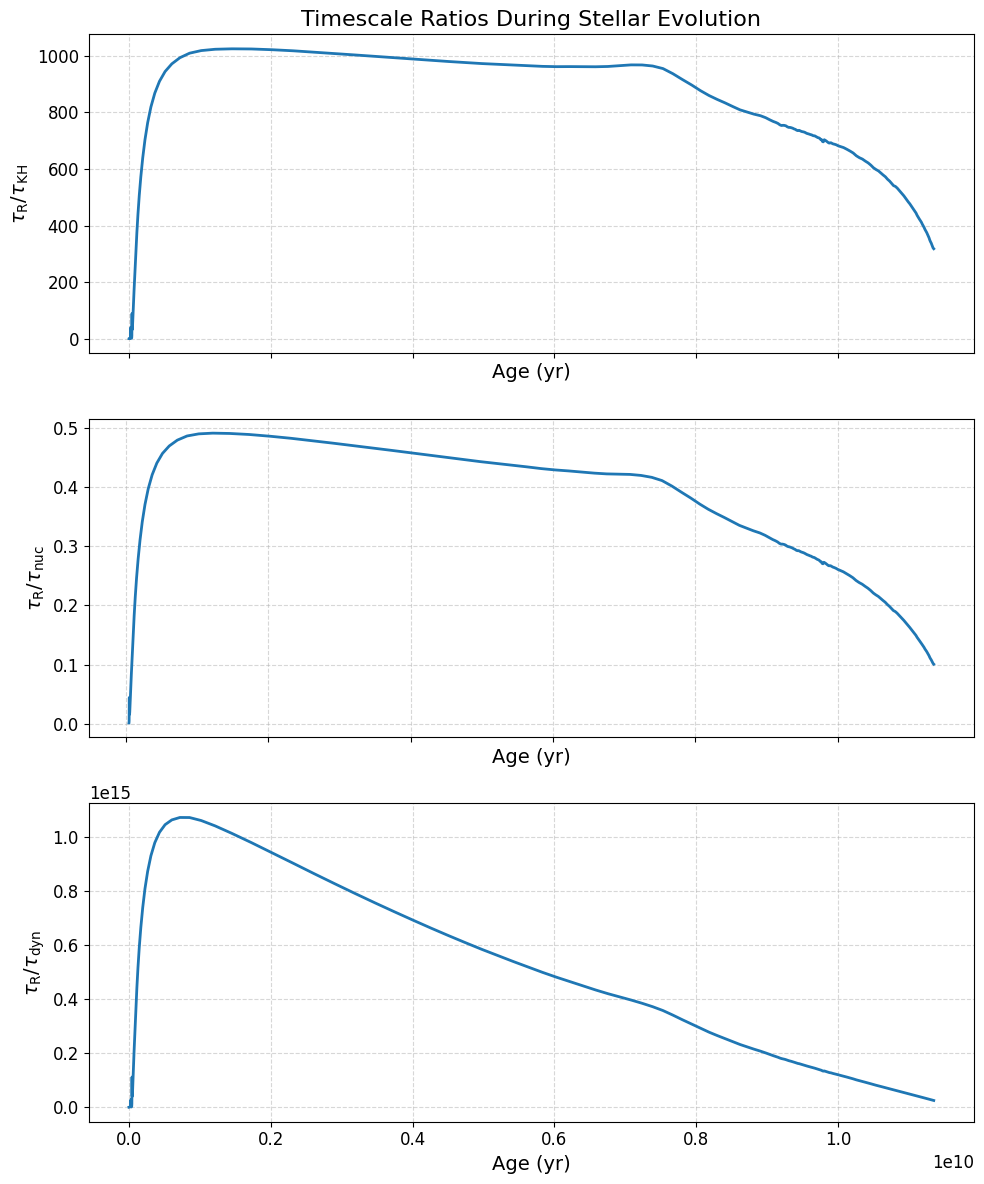

In [ ]:
r_kh = tau_R / tau_kh
r_nuc = tau_R / tau_nuc
r_dyn = tau_R / tau_dyn

# Set a global font size for better readability
plt.rcParams.update({'font.size': 12})

fig,ax=plt.subplots(3,1,figsize=(10,12)) # Increased figure height for better spacing

ax[0].plot(h.star_age, r_kh, lw=2)
ax[0].set_ylabel(r'$\tau_{\rm R}/\tau_{\rm KH}$', fontsize=14) # Using LaTeX for clarity
ax[0].set_title('Timescale Ratios During Stellar Evolution', fontsize=16) # Main title for the entire figure
ax[0].grid(alpha=0.5, linestyle='--')

ax[1].plot(h.star_age, r_nuc, lw=2)
ax[1].set_ylabel(r'$\tau_{\rm R}/\tau_{\rm nuc}$', fontsize=14) # Using LaTeX for clarity
ax[1].grid(alpha=0.5, linestyle='--')

ax[2].plot(h.star_age, r_dyn, lw=2)
ax[2].set_ylabel(r'$\tau_{\rm R}/\tau_{\rm dyn}$', fontsize=14) # Using LaTeX for clarity
ax[2].grid(alpha=0.5, linestyle='--')

for i in range(3):
    ax[i].set_xlabel('Age (yr)', fontsize=14) # Consistent x-label for all subplots
    # Only display x-axis label on the bottom-most plot
    if i < 2:
        ax[i].tick_params(labelbottom=False)

plt.tight_layout()
plt.show()

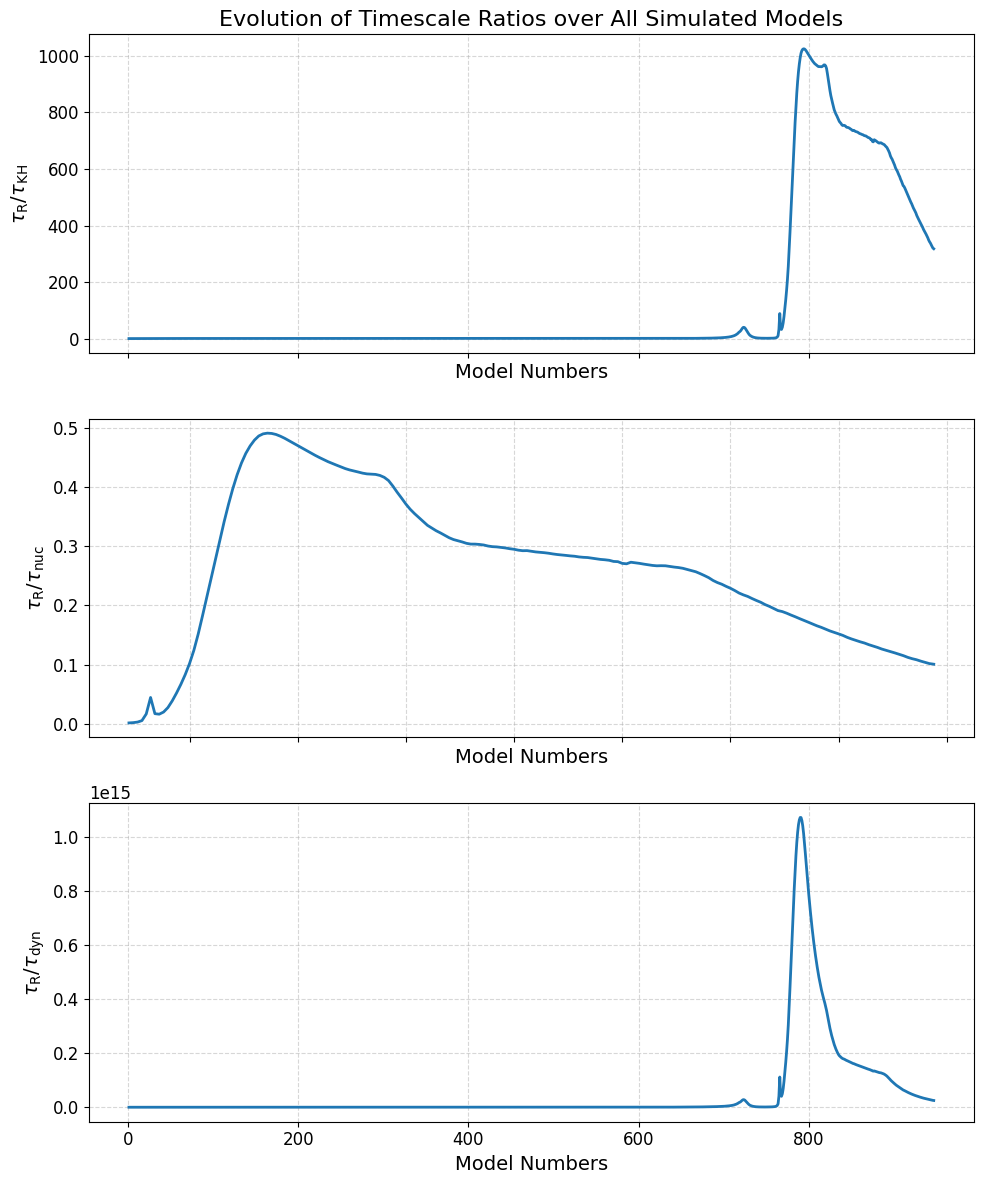

In [ ]:
r_kh = tau_R / tau_kh
r_nuc = tau_R / tau_nuc
r_dyn = tau_R / tau_dyn

# Set a global font size for better readability
plt.rcParams.update({'font.size': 12})

fig,ax=plt.subplots(3,1,figsize=(10,12)) # Increased figure height for better spacing

ax[0].plot(h.model_number, r_kh, lw=2)
ax[0].set_ylabel(r'$\tau_{\rm R}/\tau_{\rm KH}$', fontsize=14) # Using LaTeX for clarity
ax[0].set_title('Evolution of Timescale Ratios over All Simulated Models', fontsize=16) # Main title for the entire figure
ax[0].grid(alpha=0.5, linestyle='--')

ax[1].plot(h.model_number, r_nuc, lw=2)
ax[1].set_ylabel(r'$\tau_{\rm R}/\tau_{\rm nuc}$', fontsize=14) # Using LaTeX for clarity
ax[1].grid(alpha=0.5, linestyle='--')

ax[2].plot(h.model_number, r_dyn, lw=2)
ax[2].set_ylabel(r'$\tau_{\rm R}/\tau_{\rm dyn}$', fontsize=14) # Using LaTeX for clarity
ax[2].grid(alpha=0.5, linestyle='--')

for i in range(3):
    ax[i].set_xlabel('Model Numbers', fontsize=14) # Consistent x-label for all subplots
    # Only display x-axis label on the bottom-most plot
    if i < 2:
        ax[i].tick_params(labelbottom=False)

plt.tight_layout()
plt.show()

## Convective Cores and Advanced Evolutionary Stages

####General

In [ ]:
High_Star_Mass = 47.504
Low_Star_Mass = 0.665

In [ ]:
h2h = mr.MesaData('SimData/historyhigh.data')
p2p = mr.MesaData('SimData/profile5high.data')

In [ ]:
print(p2p.bulk_names)

('zone', 'mass', 'logR', 'logT', 'logRho', 'logP', 'x_mass_fraction_H', 'y_mass_fraction_He', 'z_mass_fraction_metals', 'q', 'grada', 'opacity', 'luminosity', 'gradr')


In [ ]:
print(h2h.model_number[-1])

1055


In [ ]:
import mesa_reader as mr

print("Final model =", h2h.model_number[-1])
print("Final Xc =", h2h.center_h1[-1])
print("Final age =", h2h.star_age[-1])

Final model = 1055
Final Xc = 0.008685725661625772
Final age = 4065231.6424125344


In [ ]:
print(h2h.center_h1[-1])

0.008685725661625772


In [ ]:
import mesa_reader as mr

print("Convective core mass =", h2h.mass_conv_core[-1])

print("conv_mx1_top =", h2h.conv_mx1_top[-1])
print("conv_mx1_bot =", h2h.conv_mx1_bot[-1])

Convective core mass = 19.270784597508573
conv_mx1_top = 0.404518713815514
conv_mx1_bot = 7.813138408344346e-08


####General plots for Highmass Star

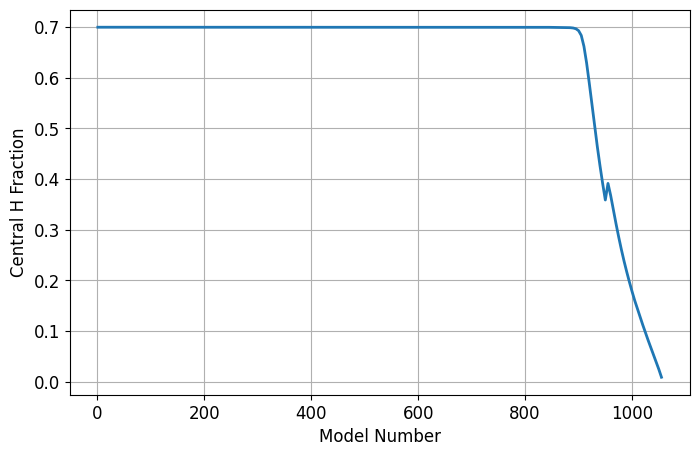

In [ ]:
h = mr.MesaData("SimData/historyhigh.data")
plt.figure(figsize=(8,5))

plt.plot(
    h.model_number,
    h.center_h1,
    lw=2
)

plt.xlabel("Model Number")
plt.ylabel("Central H Fraction")

plt.grid()
plt.show()

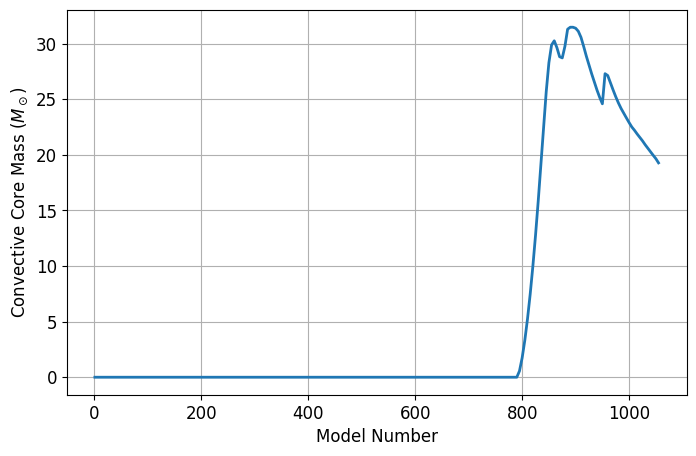

In [ ]:
h = mr.MesaData("SimData/historyhigh.data")

plt.figure(figsize=(8,5))

plt.plot(
    h.model_number,
    h.mass_conv_core,
    lw=2
)

plt.xlabel("Model Number")
plt.ylabel(r"Convective Core Mass ($M_\odot$)")

plt.grid()
plt.show()

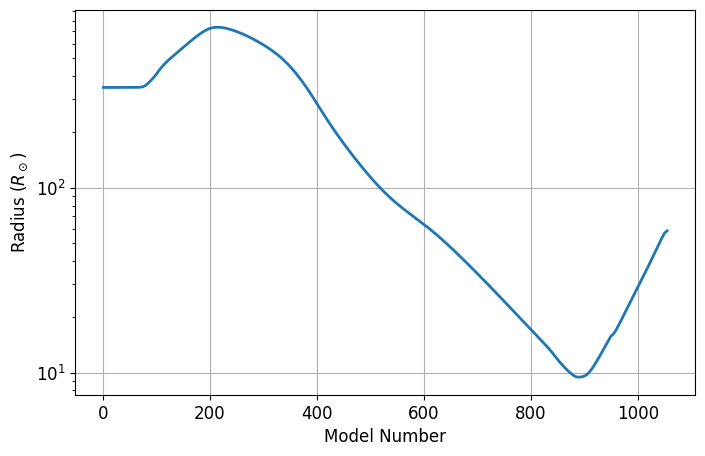

In [ ]:
h = mr.MesaData("SimData/historyhigh.data")

plt.figure(figsize=(8,5))

plt.plot(
    h.model_number,
    10**h.log_R,
    lw=2
)

plt.yscale('log')

plt.xlabel("Model Number")
plt.ylabel(r"Radius ($R_\odot$)")

plt.grid()
plt.show()

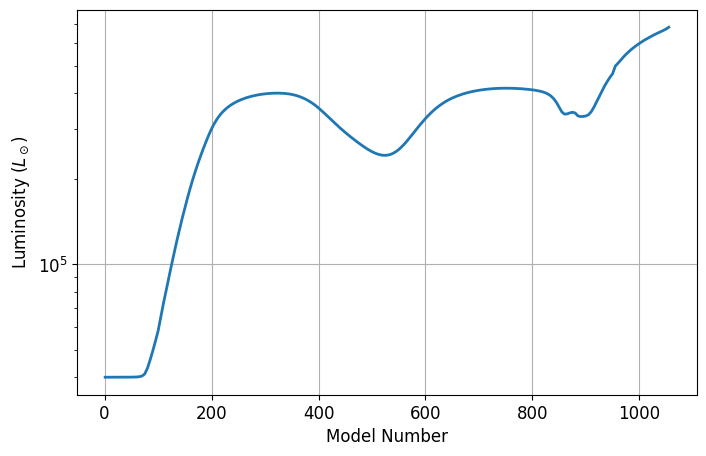

In [ ]:
h = mr.MesaData("SimData/historyhigh.data")

plt.figure(figsize=(8,5))

plt.plot(
    h.model_number,
    10**h.log_L,
    lw=2
)

plt.yscale('log')

plt.xlabel("Model Number")
plt.ylabel(r"Luminosity ($L_\odot$)")

plt.grid()
plt.show()

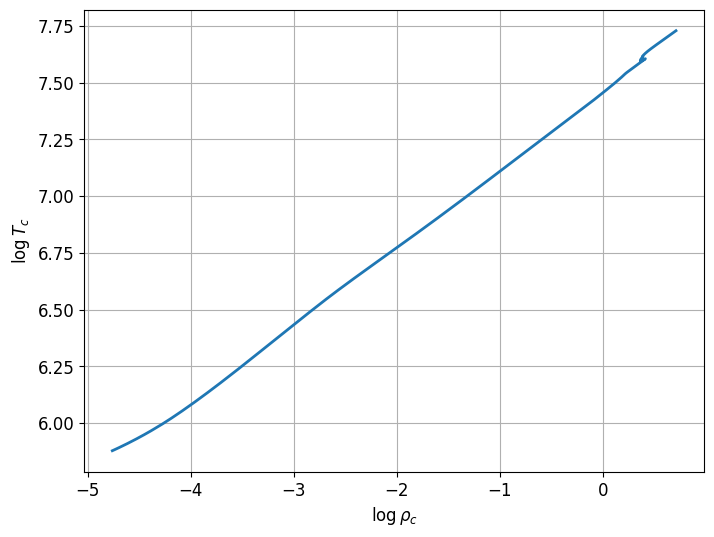

In [ ]:
h = mr.MesaData("SimData/historyhigh.data")
plt.figure(figsize=(8,6))

plt.plot(
    h.log_center_Rho,
    h.log_center_T,
    lw=2
)

plt.xlabel(r'$\log \rho_c$')
plt.ylabel(r'$\log T_c$')

plt.grid()
plt.show()

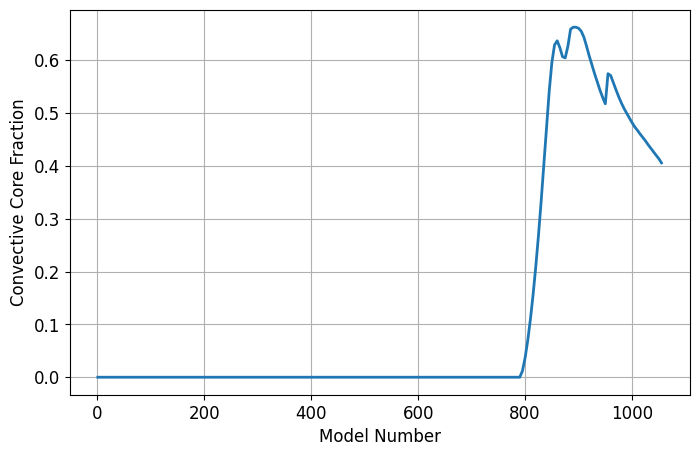

In [ ]:
h = mr.MesaData("SimData/historyhigh.data")

qcore = h.mass_conv_core / h.star_mass

plt.figure(figsize=(8,5))

plt.plot(
    h.model_number,
    qcore,
    lw=2
)

plt.xlabel("Model Number")
plt.ylabel("Convective Core Fraction")

plt.grid()
plt.show()

####Convective core Evolution and Schwarzschild Stability

In [ ]:
h = mr.MesaData("SimData/historyhigh.data")

Lnuc = 10**h.log_Lnuc
L    = 10**h.log_L

ratio = Lnuc/L

zams = np.argmax(ratio > 0.99)

print("ZAMS model =", h.model_number[zams])
print("ZAMS age =", h.star_age[zams])

tams = len(h.model_number)-1

print("TAMS model =", h.model_number[tams])
print("TAMS age =", h.star_age[tams])

ZAMS model = 883
ZAMS age = 17759.11340256607
TAMS model = 1055
TAMS age = 4065231.6424125344


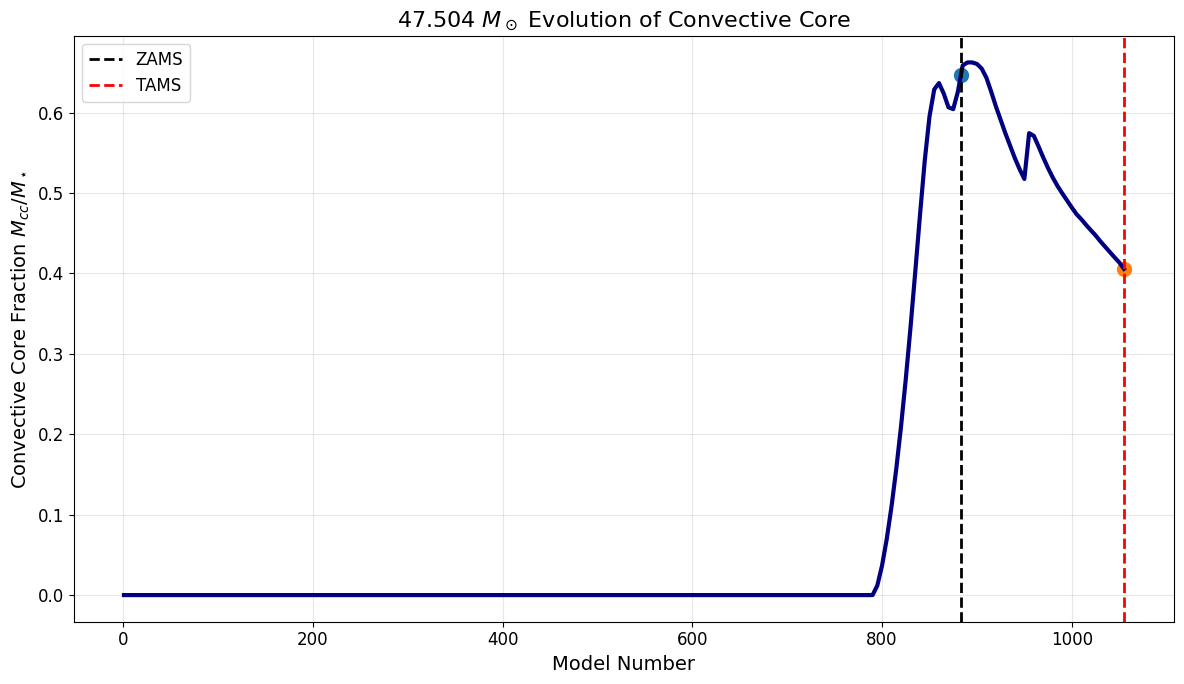

In [ ]:
h = mr.MesaData("SimData/historyhigh.data")

qcore = h.mass_conv_core / h.star_mass

plt.figure(figsize=(12,7))

plt.plot(
    h.model_number,
    qcore,
    lw=3,
    color='navy'
)

plt.axvline(
    h.model_number[zams],
    color='black',
    ls='--',
    lw=2,
    label='ZAMS'
)

plt.axvline(
    h.model_number[tams],
    color='red',
    ls='--',
    lw=2,
    label='TAMS'
)

plt.scatter(
    h.model_number[zams],
    qcore[zams],
    s=100
)

plt.scatter(
    h.model_number[tams],
    qcore[tams],
    s=100
)

plt.xlabel("Model Number", fontsize=14)

plt.ylabel(
    r'Convective Core Fraction $M_{cc}/M_\star$',
    fontsize=14
)

plt.title(
    r'47.504 $M_\odot$ Evolution of Convective Core',
    fontsize=16
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

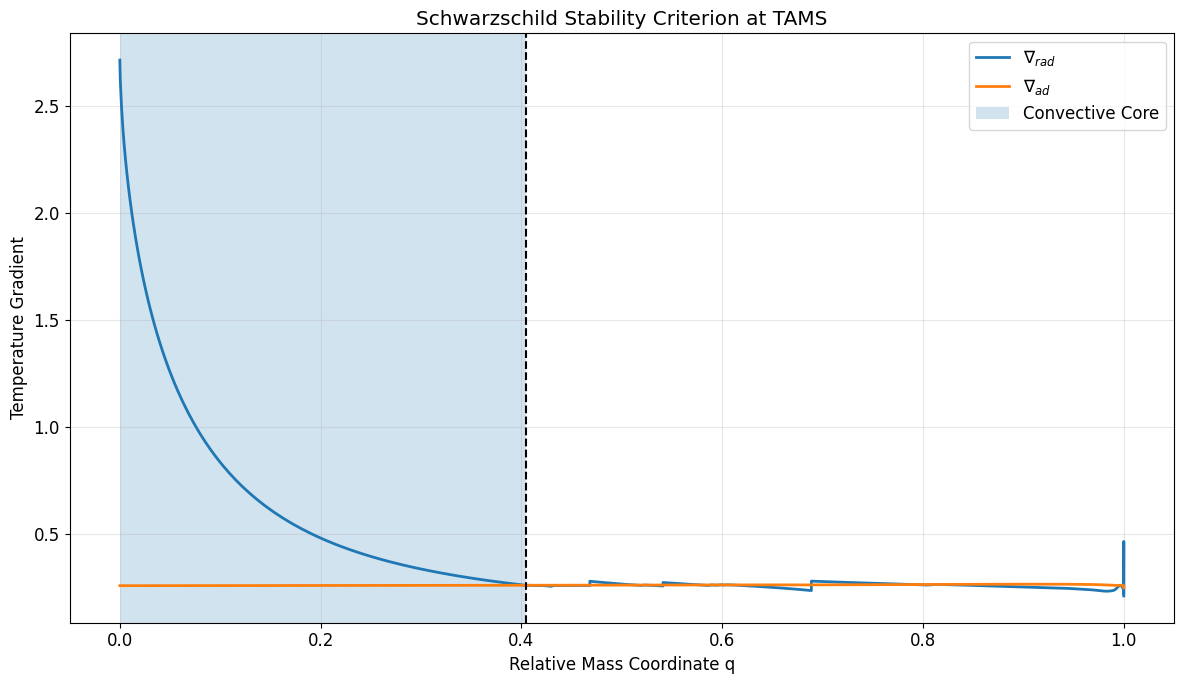

In [ ]:
p = mr.MesaData("SimData/profile5high.data")

plt.figure(figsize=(12,7))

plt.plot(
    p.q,
    p.gradr,
    lw=2,
    label=r'$\nabla_{rad}$'
)

plt.plot(
    p.q,
    p.grada,
    lw=2,
    label=r'$\nabla_{ad}$'
)

plt.axvspan(
    0,
    0.4045,
    alpha=0.2,
    label='Convective Core'
)

plt.axvline(
    0.4045,
    color='k',
    ls='--'
)

plt.xlabel("Relative Mass Coordinate q")

plt.ylabel("Temperature Gradient")

plt.title(
    "Schwarzschild Stability Criterion at TAMS"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

####Opacity and Luminosity

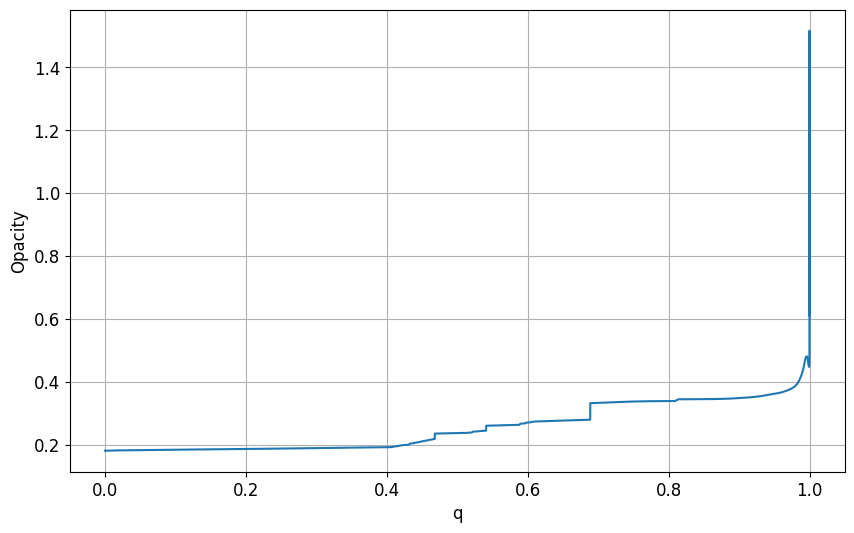

In [ ]:
p = mr.MesaData("SimData/profile5high.data")
plt.figure(figsize=(10,6))

plt.plot(p.q, p.opacity)
plt.xlabel("q")
plt.ylabel("Opacity")
plt.grid()

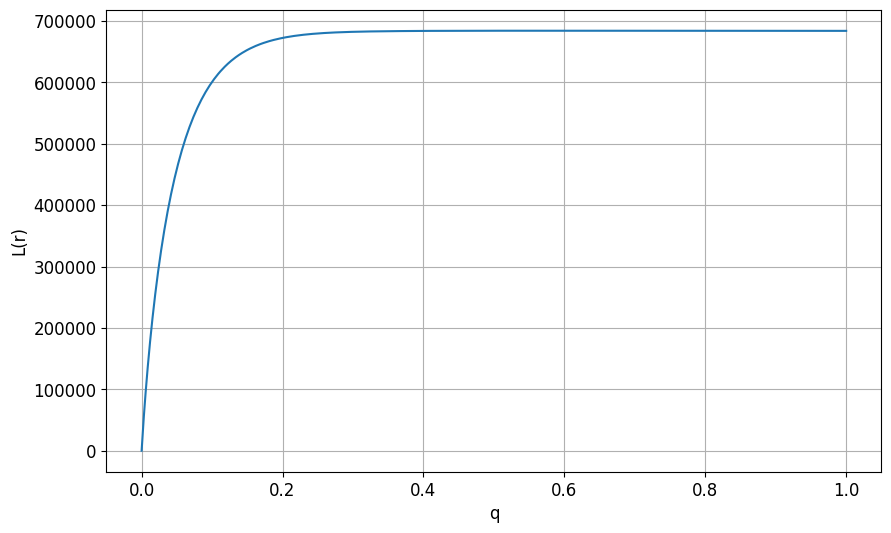

In [ ]:
p = mr.MesaData("SimData/profile5high.data")
plt.figure(figsize=(10,6))

plt.plot(p.q, p.luminosity)
plt.xlabel("q")
plt.ylabel("L(r)")
plt.grid()

+###Highmass vs Lowmass Star HR Track

In [ ]:
h = mr.MesaData("SimData/historyhigh.data")

print("--"*50)
print("1st phase Highmass:")
print("Final model =", h.model_number[-1])
print("Final age =", h.star_age[-1])

print("center_h1 =", h.center_h1[-1])
print("center_he4 =", h.center_he4[-1])

print("log_L =", h.log_L[-1])
print("log_Teff =", h.log_Teff[-1])

print("log_center_T =", h.log_center_T[-1])
print("log_center_Rho =", h.log_center_Rho[-1])
print("--"*50)

----------------------------------------------------------------------------------------------------
1st phase Highmass:
Final model = 1055
Final age = 4065231.6424125344
center_h1 = 0.008685725661625772
center_he4 = 0.9719157370758763
log_L = 5.835013034469529
log_Teff = 4.337196465101798
log_center_T = 7.72936961203089
log_center_Rho = 0.7093082001139375
----------------------------------------------------------------------------------------------------


In [ ]:
h = mr.MesaData("SimData/2historyhigh.data")

print("--"*50)
print("2nd phase Highmass:")
print("Final model =", h.model_number[-1])
print("Final age =", h.star_age[-1])

print("center_h1 =", h.center_h1[-1])
print("center_he4 =", h.center_he4[-1])

print("log_L =", h.log_L[-1])
print("log_Teff =", h.log_Teff[-1])

print("log_center_T =", h.log_center_T[-1])
print("log_center_Rho =", h.log_center_Rho[-1])
print("--"*50)

----------------------------------------------------------------------------------------------------
2nd phase Highmass:
Final model = 2799
Final age = 4464050.75750334
center_h1 = 0.0
center_he4 = 0.009990960839501994
log_L = 5.843591955663481
log_Teff = 3.5631498946632267
log_center_T = 8.476374429872912
log_center_Rho = 3.0521346588766796
----------------------------------------------------------------------------------------------------


In [ ]:
h = mr.MesaData("SimData/Lowhistory.data")

print("--"*50)
print("Lowmass:")
print("Final model =", h.model_number[-1])
print("Final age =", h.star_age[-1])

print("center_h1 =", h.center_h1[-1])
print("center_he4 =", h.center_he4[-1])

print("log_L =", h.log_L[-1])
print("log_Teff =", h.log_Teff[-1])

print("log_center_T =", h.log_center_T[-1])
print("log_center_Rho =", h.log_center_Rho[-1])
print("--"*50)

----------------------------------------------------------------------------------------------------
Lowmass:
Final model = 21706
Final age = 54772198571.254234
center_h1 = 0.0
center_he4 = 0.009663253073132068
log_L = 1.8155577853782838
log_Teff = 3.6559325620488483
log_center_T = 8.196329727448092
log_center_Rho = 4.63133360351058
----------------------------------------------------------------------------------------------------


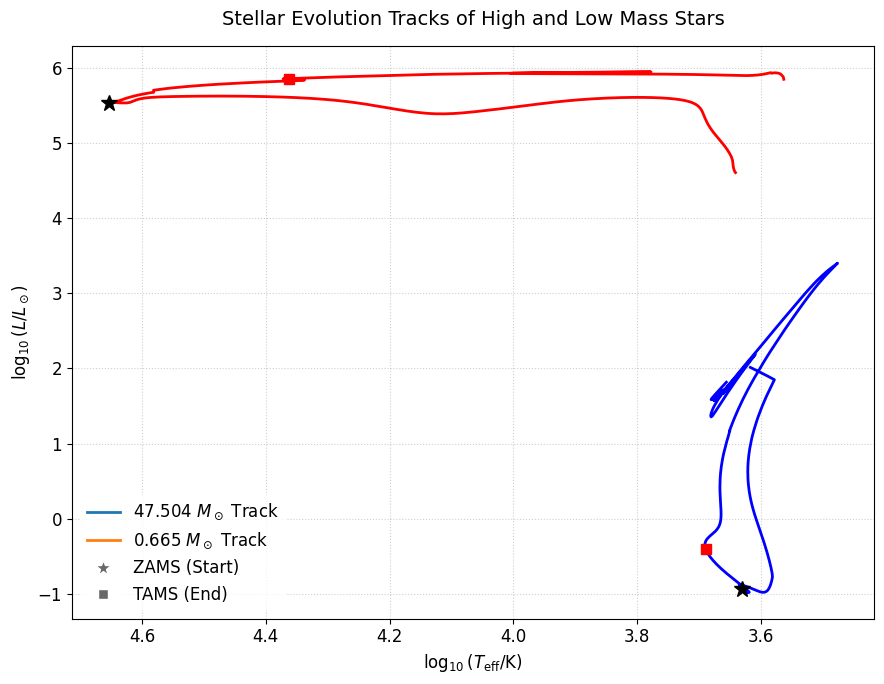

In [ ]:
hh = mr.MesaData("SimData/2historyhigh.data")
hl = mr.MesaData("SimData/Lowhistory.data")

# Converting Log to Linear for luminosity ratios
hLnuc = 10**hh.log_Lnuc
hL    = 10**hh.log_L

lLnuc = 10**hl.log_Lnuc
lL    = 10**hl.log_L

hratio = hLnuc / hL
lratio = lLnuc / lL

# Array indices for ZAMS and TAMS
hzams_idx = np.argmax(hratio > 0.99)
lzams_idx = np.argmax(lratio > 0.99)

htams_idx = np.argmax(hh.center_h1 < 1e-3)
ltams_idx = np.argmax(hl.center_h1 < 1e-3)

# Extract (X, Y) coordinates for the markers
hzams_x, hzams_y = hh.log_Teff[hzams_idx], hh.log_L[hzams_idx]
htams_x, htams_y = hh.log_Teff[htams_idx], hh.log_L[htams_idx]

lzams_x, lzams_y = hl.log_Teff[lzams_idx], hl.log_L[lzams_idx]
ltams_x, ltams_y = hl.log_Teff[ltams_idx], hl.log_L[ltams_idx]

# 5. Plotting
plt.figure(figsize=(9, 7))

# High mass track (47.504 Msun)
plt.plot(hh.log_Teff, hh.log_L, label=r'47.504 $M_\odot$', color='red', lw=2)
plt.plot(hzams_x, hzams_y, marker='*', color='black', ms=12, ls='none')
plt.plot(htams_x, htams_y, marker='s', color='red', ms=7, ls='none')

# Low mass track (0.665 Msun)
plt.plot(hl.log_Teff, hl.log_L, label=r'0.665 $M_\odot$', color='blue', lw=2)
plt.plot(lzams_x, lzams_y, marker='*', color='black', ms=12, ls='none')
plt.plot(ltams_x, ltams_y, marker='s', color='red', ms=7, ls='none')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#1f77b4', lw=2, label=r'47.504 $M_\odot$ Track'),
    Line2D([0], [0], color='#ff7f0e', lw=2, label=r'0.665 $M_\odot$ Track'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='dimgray', ms=12, label='ZAMS (Start)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='dimgray', ms=7, label='TAMS (End)')
]
plt.legend(handles=legend_elements, loc='best', frameon=True, facecolor='white', edgecolor='none')

# Professional formatting
plt.gca().invert_xaxis()  # Hotter stars on the left
plt.xlabel(r'$\log_{10}(T_{\rm eff} / \rm K)$', fontsize=12)
plt.ylabel(r'$\log_{10}(L / L_\odot)$', fontsize=12)
plt.title('Stellar Evolution Tracks of High and Low Mass Stars', fontsize=14, pad=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

####Central Conditions

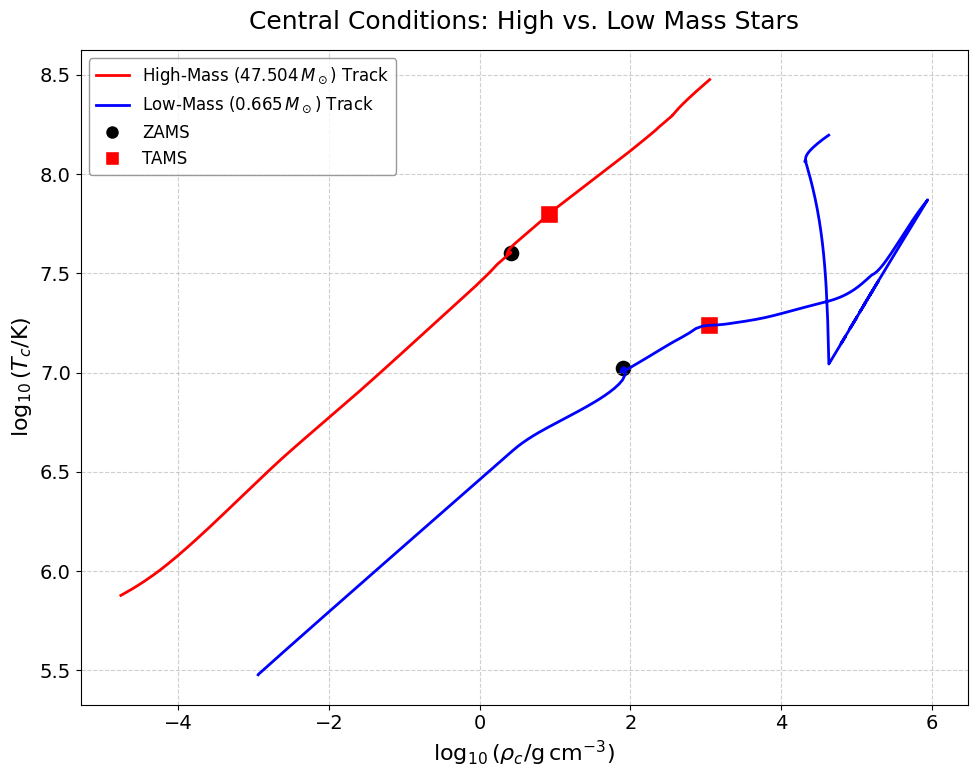

In [ ]:
from matplotlib.lines import Line2D

plt.rcParams.update({'font.size': 14})

hh = mr.MesaData("SimData/2historyhigh.data")
hl = mr.MesaData("SimData/Lowhistory.data")

hLnuc = 10**hh.log_Lnuc
hL    = 10**hh.log_L

lLnuc = 10**hl.log_Lnuc
lL    = 10**hl.log_L

hratio = hLnuc / hL
lratio = lLnuc / lL

hzams_idx = np.argmax(hratio > 0.99)
lzams_idx = np.argmax(lratio > 0.99)

htams_idx = np.argmax(hh.center_h1 < 1e-3)
ltams_idx = np.argmax(hl.center_h1 < 1e-3)

fig, ax = plt.subplots(figsize=(10, 8))


ax.plot(
    hh.log_center_Rho,
    hh.log_center_T,
    color='red', # Explicit color
    lw=2,
    label='_nolegend_'
)

ax.plot(
    hl.log_center_Rho,
    hl.log_center_T,
    color='blue', #
    lw=2,
    label='_nolegend_'
)

ax.scatter(
    hh.log_center_Rho[hzams_idx],
    hh.log_center_T[hzams_idx],
    s=150,
    color='black',
    marker='o',
    edgecolor='white',
    linewidth=1,
    label='_nolegend_'
)

ax.scatter(
    hh.log_center_Rho[htams_idx],
    hh.log_center_T[htams_idx],
    s=150,
    color='red',
    marker='s',
    edgecolor='white',
    linewidth=1,
    label='_nolegend_'
)

ax.scatter(
    hl.log_center_Rho[lzams_idx],
    hl.log_center_T[lzams_idx],
    s=150,
    color='black',
    marker='o',
    edgecolor='white',
    linewidth=1,
    label='_nolegend_'
)

ax.scatter(
    hl.log_center_Rho[ltams_idx],
    hl.log_center_T[ltams_idx],
    s=150,
    color='red',
    marker='s',
    edgecolor='white',
    linewidth=1,
    label='_nolegend_'
)

legend_elements = [
    Line2D([0], [0], color='red', lw=2, label=r'High-Mass ($47.504\,M_\odot$) Track'),
    Line2D([0], [0], color='blue', lw=2, label=r'Low-Mass ($0.665\,M_\odot$) Track'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markeredgecolor='white', ms=10, label='ZAMS'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markeredgecolor='white', ms=10, label='TAMS')
]
ax.set_xlabel(r'$\log_{10}(\rho_c / \rm{g}\,\rm{cm}^{-3})$', fontsize=16)
ax.set_ylabel(r'$\log_{10}(T_c / \rm{K})$', fontsize=16)
ax.set_title('Central Conditions: High vs. Low Mass Stars', fontsize=18, pad=15)

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(handles=legend_elements, loc='best', frameon=True, facecolor='white', edgecolor='gray', fontsize=12)

plt.tight_layout()
plt.show()

##Theoretical Framework and Numerical Implementation


####General

In [ ]:
0.258

0.258

In [ ]:
import mesa_reader as mr

h = mr.MesaData("SimData/refhistory.data")

print("Final model =", h.model_number[-1])
print("Final age =", h.star_age[-1])
print("Final Xc =", h.center_h1[-1])

print(h.bulk_names)

Final model = 125
Final age = 14763639.934415732
Final Xc = 0.039140120931237296
('model_number', 'num_zones', 'star_age', 'log_dt', 'star_mass', 'log_xmstar', 'log_abs_mdot', 'mass_conv_core', 'conv_mx1_top', 'conv_mx1_bot', 'conv_mx2_top', 'conv_mx2_bot', 'mx1_top', 'mx1_bot', 'mx2_top', 'mx2_bot', 'log_LH', 'log_LHe', 'log_LZ', 'log_Lnuc', 'pp', 'cno', 'tri_alfa', 'epsnuc_M_1', 'epsnuc_M_2', 'epsnuc_M_3', 'epsnuc_M_4', 'epsnuc_M_5', 'epsnuc_M_6', 'epsnuc_M_7', 'epsnuc_M_8', 'he_core_mass', 'c_core_mass', 'o_core_mass', 'si_core_mass', 'fe_core_mass', 'neutron_rich_core_mass', 'log_Teff', 'log_L', 'log_R', 'log_g', 'v_div_csound_surf', 'surf_avg_v_rot', 'log_center_T', 'log_center_Rho', 'log_cntr_P', 'log_cntr_Rho', 'log_cntr_T', 'center_mu', 'center_ye', 'center_abar', 'center_h1', 'center_he4', 'center_c12', 'center_o16', 'surface_c12', 'surface_o16', 'total_mass_h1', 'total_mass_he4', 'num_retries', 'num_backups', 'num_iters')


In [ ]:
import mesa_reader as mr
import numpy as np

h = mr.MesaData("SimData/refhistory.data")

print("Age =", h.star_age[-1])

print("Convective core mass =",
      h.mass_conv_core[-1])

print("Convective core fraction =",
      h.mass_conv_core[-1]/h.star_mass[-1])

print("Surface rotation =",
      h.surf_avg_v_rot[-1])

print("logL =", h.log_L[-1])

print("logTeff =", h.log_Teff[-1])

print("logg =", h.log_g[-1])

Age = 14763639.934415732
Convective core mass = 1.8426584135130637
Convective core fraction = 0.15355486779275532
Surface rotation = 208.48602165302688
logL = 4.26292142320688
logTeff = 4.329025081332576
logg = 3.523731828678923


In [ ]:
import mesa_reader as mr
import numpy as np

h = mr.MesaData("SimData/Overshoothistory.data")

print("Age =", h.star_age[-1])

print("Convective core mass =",
      h.mass_conv_core[-1])

print("Convective core fraction =",
      h.mass_conv_core[-1]/h.star_mass[-1])

print("Surface rotation =",
      h.surf_avg_v_rot[-1])

print("logL =", h.log_L[-1])

print("logTeff =", h.log_Teff[-1])

print("logg =", h.log_g[-1])

Age = 28333812.900264002
Convective core mass = 6.771966535731654
Convective core fraction = 0.5643305446443044
Surface rotation = 77.6782529864493
logL = 5.0465796718405045
logTeff = 4.035164655409812
logg = 1.5646318763542404


In [ ]:
import mesa_reader as mr
import numpy as np

h = mr.MesaData("SimData/Overshoothistory.data")

print("Age =", h.star_age[-1])

print("Convective core mass =",
      h.mass_conv_core[-1])

print("Convective core fraction =",
      h.mass_conv_core[-1]/h.star_mass[-1])

print("Surface rotation =",
      h.surf_avg_v_rot[-1])

print("logL =", h.log_L[-1])

print("logTeff =", h.log_Teff[-1])

print("logg =", h.log_g[-1])

Age = 28333812.900264002
Convective core mass = 6.771966535731654
Convective core fraction = 0.5643305446443044
Surface rotation = 77.6782529864493
logL = 5.0465796718405045
logTeff = 4.035164655409812
logg = 1.5646318763542404


####HR Track

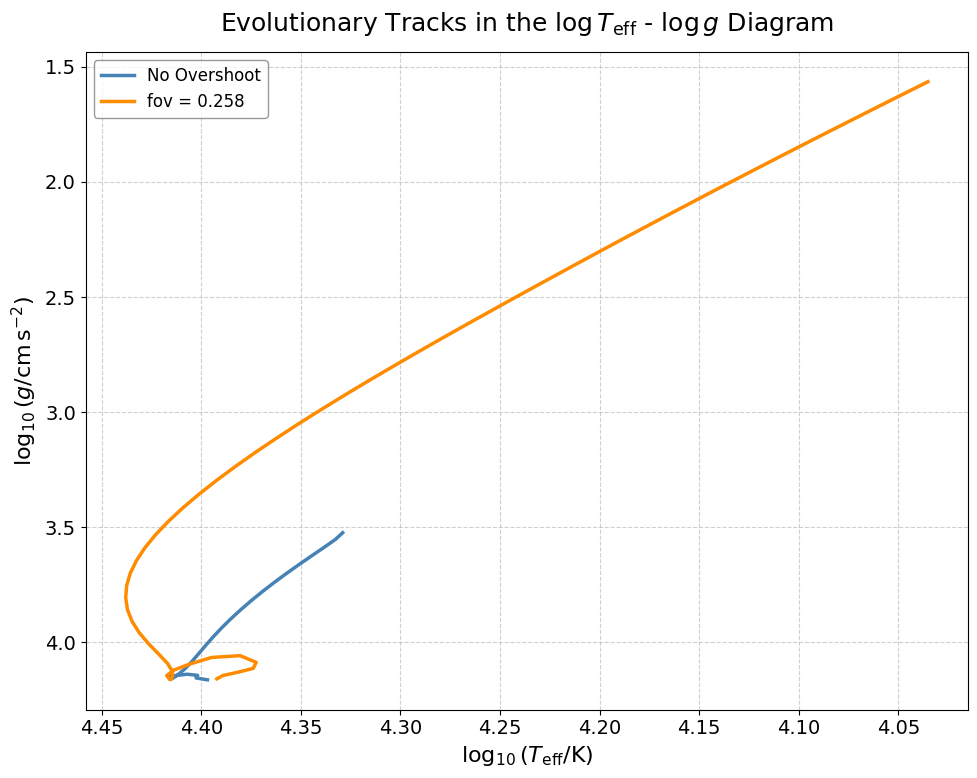

In [ ]:
import mesa_reader as mr
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

ref = mr.MesaData("SimData/refhistory.data")
ov  = mr.MesaData("SimData/Overshoothistory.data")

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(
    ref.log_Teff,
    ref.log_g,
    lw=2.5,
    label='No Overshoot',
    color='steelblue'
)

ax.plot(
    ov.log_Teff,
    ov.log_g,
    lw=2.5,
    label='fov = 0.258',
    color='darkorange'
)

ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel(r'$\log_{10}(T_{\rm eff} / \rm{K})$', fontsize=16)
ax.set_ylabel(r'$\log_{10}(g / \rm{cm}\,\rm{s}^{-2})$', fontsize=16)

ax.set_title(r'Evolutionary Tracks in the $\log T_{\rm eff}$ - $\log g$ Diagram', fontsize=18, pad=15)

ax.legend(fontsize=12, frameon=True, facecolor='white', edgecolor='gray', loc='best')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

####Different Fov's

In [ ]:
import mesa_reader as mr
import numpy as np

h = mr.MesaData("SimData/OVER2history.data")

print("Age =", h.star_age[-1])

print("Convective core mass =",
      h.mass_conv_core[-1])

print("Convective core fraction =",
      h.mass_conv_core[-1]/h.star_mass[-1])

print("Surface rotation =",
      h.surf_avg_v_rot[-1])

print("logL =", h.log_L[-1])

print("logTeff =", h.log_Teff[-1])

print("logg =", h.log_g[-1])

Age = 20328079.55171259
Convective core mass = 2.885099989855769
Convective core fraction = 0.24042499915464743
Surface rotation = 125.60930692522047
logL = 4.522639631600278
logTeff = 4.244240141477418
logg = 2.9248738608648908


In [ ]:
import mesa_reader as mr
import numpy as np

h = mr.MesaData("SimData/OVER3history.data")

print("Age =", h.star_age[-1])

print("Convective core mass =",
      h.mass_conv_core[-1])

print("Convective core fraction =",
      h.mass_conv_core[-1]/h.star_mass[-1])

print("Surface rotation =",
      h.surf_avg_v_rot[-1])

print("logL =", h.log_L[-1])

print("logTeff =", h.log_Teff[-1])

print("logg =", h.log_g[-1])

Age = 23662590.394364264
Convective core mass = 4.083204289905483
Convective core fraction = 0.34026702415879023
Surface rotation = 75.52282273883323
logL = 4.736954247261113
logTeff = 4.135789518859655
logg = 2.2767567547330048


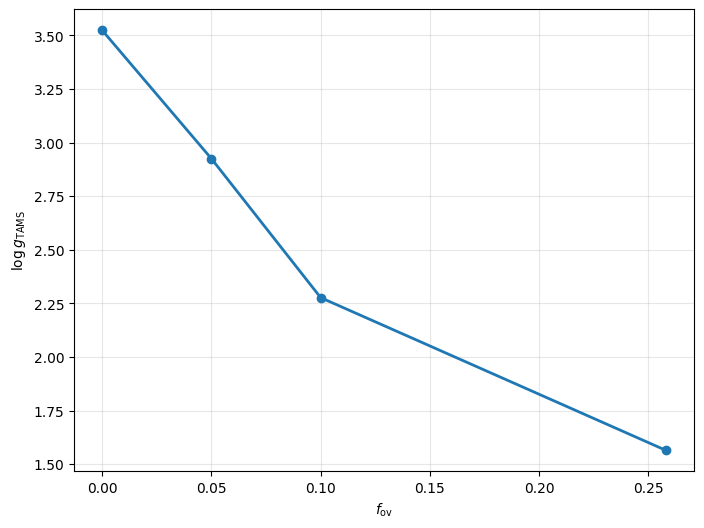

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fov = np.array([0.00,0.05,0.10,0.258])

logg = np.array([
    3.5237,
    2.9249,
    2.2768,
    1.5646
])

plt.figure(figsize=(8,6))

plt.plot(
    fov,
    logg,
    'o-',
    lw=2
)

plt.xlabel(r'$f_{\rm ov}$')

plt.ylabel(r'$\log g_{\rm TAMS}$')

plt.grid(alpha=0.3)

plt.show()

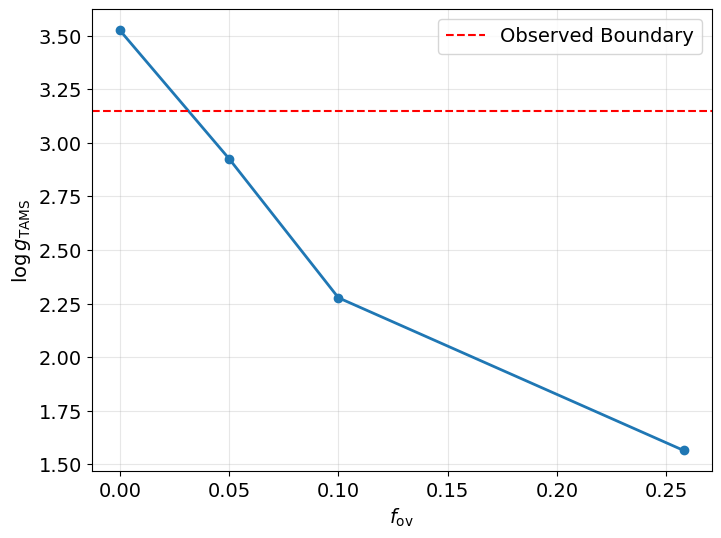

In [ ]:
fov  = [0.0,0.05,0.10,0.258]
logg = [3.524,2.925,2.277,1.565]

plt.figure(figsize=(8,6))

plt.plot(fov,logg,'o-',lw=2)

plt.axhline(
    3.15,
    color='red',
    ls='--',
    label='Observed Boundary'
)

plt.xlabel(r'$f_{\rm ov}$')
plt.ylabel(r'$\log g_{\rm TAMS}$')

plt.legend()
plt.grid(alpha=0.3)

##Nuclear Networks and Pre-Main-Sequence Deuterium Fusion

####General

In [ ]:
h = mr.MesaData("SimData/e4history.data")
print(h.bulk_names)
p = mr.MesaData("SimData/e4profile80.data")
print(p.bulk_names)

('model_number', 'num_zones', 'star_age', 'log_dt', 'star_mass', 'log_xmstar', 'log_abs_mdot', 'mass_conv_core', 'conv_mx1_top', 'conv_mx1_bot', 'conv_mx2_top', 'conv_mx2_bot', 'mx1_top', 'mx1_bot', 'mx2_top', 'mx2_bot', 'log_LH', 'log_LHe', 'log_LZ', 'log_Lnuc', 'pp', 'cno', 'tri_alfa', 'epsnuc_M_1', 'epsnuc_M_2', 'epsnuc_M_3', 'epsnuc_M_4', 'epsnuc_M_5', 'epsnuc_M_6', 'epsnuc_M_7', 'epsnuc_M_8', 'he_core_mass', 'c_core_mass', 'o_core_mass', 'si_core_mass', 'fe_core_mass', 'neutron_rich_core_mass', 'log_Teff', 'log_L', 'log_R', 'log_g', 'v_div_csound_surf', 'log_center_T', 'log_center_Rho', 'log_cntr_P', 'log_cntr_Rho', 'log_cntr_T', 'center_mu', 'center_ye', 'center_abar', 'center_h1', 'center_he4', 'center_c12', 'center_o16', 'surface_c12', 'surface_o16', 'total_mass_h1', 'total_mass_he4', 'num_retries', 'num_backups', 'num_iters')
('zone', 'mass', 'logR', 'logT', 'logRho', 'logP', 'x_mass_fraction_H', 'y_mass_fraction_He', 'z_mass_fraction_metals', 'grada', 'h1', 'h2', 'he3', 'he4'

In [ ]:
import mesa_reader as mr
import numpy as np

h = mr.MesaData("SimData/e4history.data")

print("Initial age =", h.star_age[0])
print("Final age   =", h.star_age[-1])

print("Initial logR =", h.log_R[0])
print("Final logR   =", h.log_R[-1])

print("Initial Tc =", h.log_center_T[0])
print("Final Tc   =", h.log_center_T[-1])

print("Initial center_h1 =", h.center_h1[0])
print("Final center_h1   =", h.center_h1[-1])

Initial age = 1e-05
Final age   = 1253478965.7590513
Initial logR = 1.2952440340742695
Final logR   = -0.20237753751293308
Initial Tc = 5.477877376332186
Final Tc   = 7.002374891767821
Initial center_h1 = 0.7000000000000001
Final center_h1   = 0.6798196193860541


In [ ]:
p = mr.MesaData("SimData/e4profile80.data")

print("Maximum H2 =", np.max(p.h2))
print("Minimum H2 =", np.min(p.h2))

print("Maximum He3 =", np.max(p.he3))
print("Maximum He4 =", np.max(p.he4))

Maximum H2 = 1.7946290850415642e-17
Minimum H2 = 6.789878220532752e-18
Maximum He3 = 0.0025678456058813998
Maximum He4 = 0.29970469973245234


####Abundance Profiles

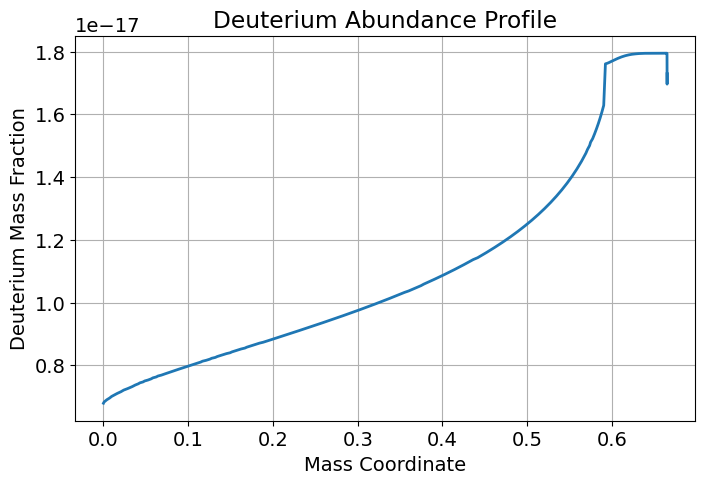

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(p.mass, p.h2, lw=2)

plt.xlabel("Mass Coordinate")
plt.ylabel("Deuterium Mass Fraction")
plt.title("Deuterium Abundance Profile")

plt.grid()
plt.show()

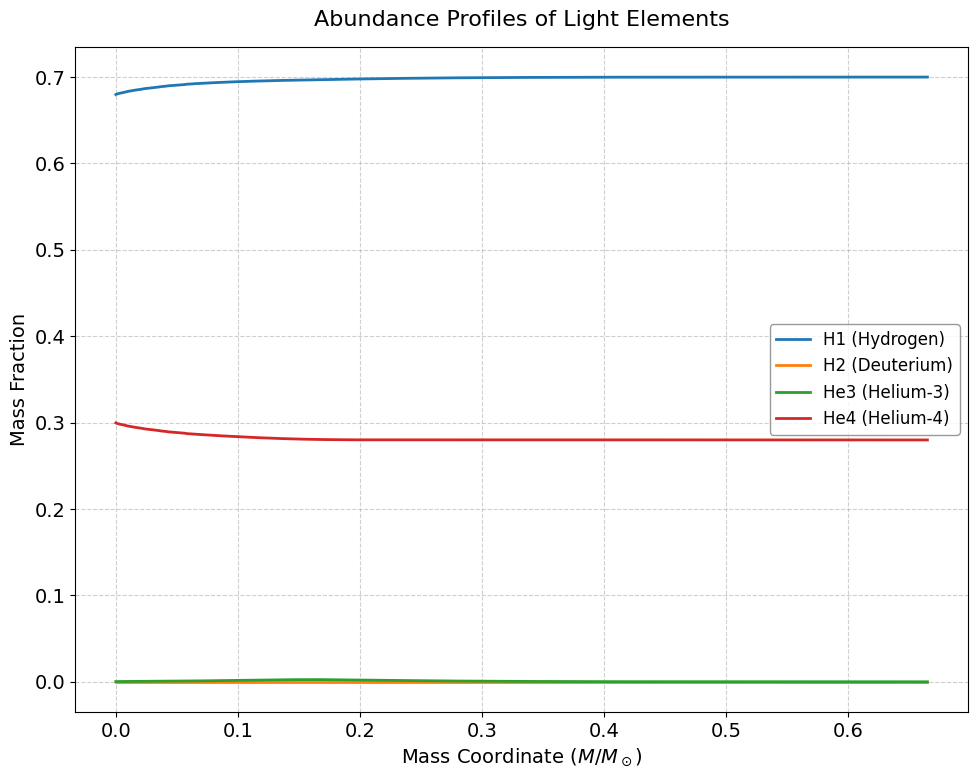

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.plot(p.mass, p.h1, label="H1 (Hydrogen)", lw=2)
plt.plot(p.mass, p.h2, label="H2 (Deuterium)", lw=2)
plt.plot(p.mass, p.he3, label="He3 (Helium-3)", lw=2)
plt.plot(p.mass, p.he4, label="He4 (Helium-4)", lw=2)

plt.legend(fontsize=12, frameon=True, edgecolor='gray')
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlabel(r"Mass Coordinate ($M/M_\odot$)", fontsize=14)
plt.ylabel("Mass Fraction", fontsize=14)
plt.title("Abundance Profiles of Light Elements", fontsize=16, pad=15)
plt.tight_layout()
plt.show()

####Hot Deuterium Burning

In [ ]:
8.5

8.5

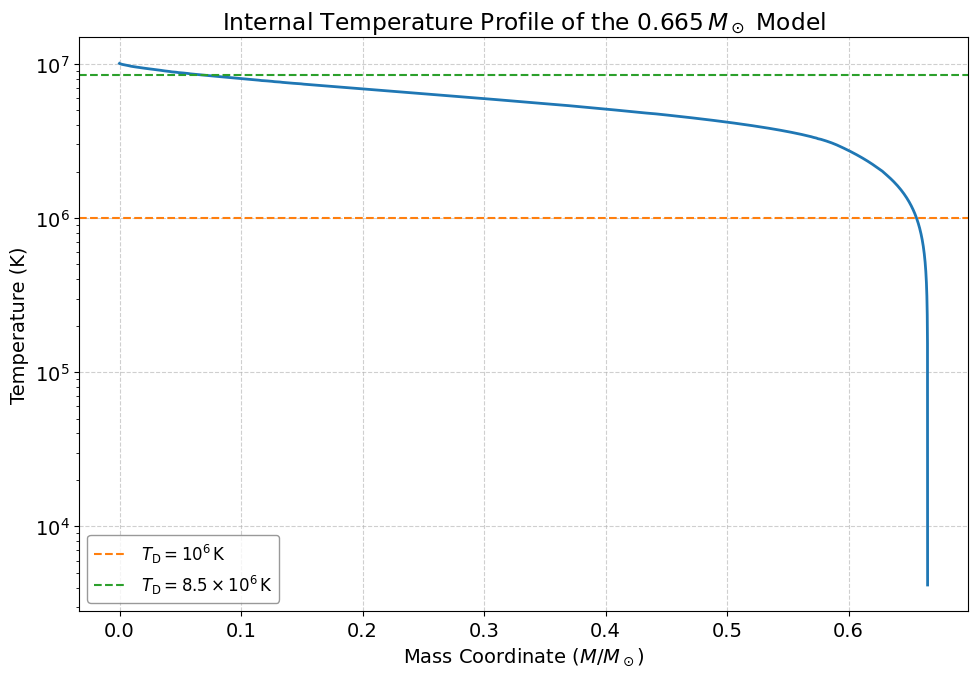

In [ ]:
p = mr.MesaData("SimData/e4profile80.data")

plt.figure(figsize=(10,7))
plt.plot(p.mass, 10**p.logT, lw=2)

plt.xlabel(r'Mass Coordinate ($M/M_\odot$)', fontsize=14)
plt.ylabel('Temperature (K)', fontsize=14)

plt.axhline(
    1e6,
    ls='--',
    color='C1',
    label=r'$T_{\rm D}=10^6\,{\rm K}$'
)

plt.axhline(
    8.5e6,
    ls='--',
    color='C2',
    label=r'$T_{\rm D}=8.5\times10^6\,{\rm K}$'
)

plt.yscale('log')
plt.title(
    r'Internal Temperature Profile of the $0.665\,M_\odot$ Model'
)
plt.legend(fontsize=12, frameon=True, edgecolor='gray')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

####Radius Evolution

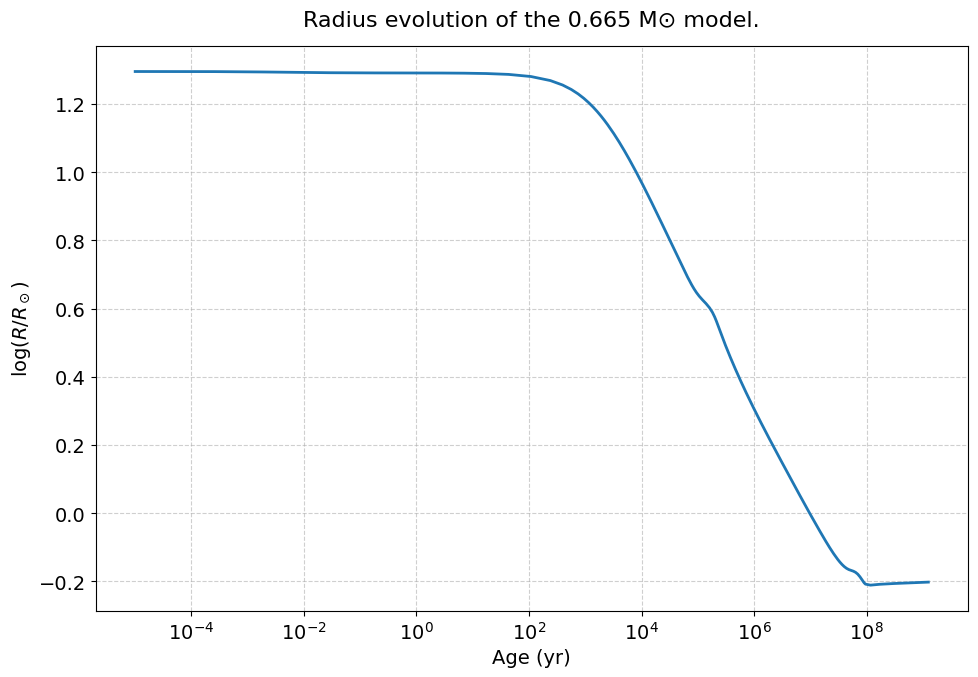

In [ ]:
h = mr.MesaData("SimData/e4history.data")
plt.figure(figsize=(10,7))
plt.plot(h.star_age, h.log_R, lw=2)
plt.xscale('log')
plt.xlabel('Age (yr)', fontsize=14)
plt.ylabel(r'$\log(R/R_\odot)$', fontsize=14)
plt.title('Radius evolution of the 0.665 M⊙ model.', fontsize=16, pad=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##Data Not available (Private Data)
###Only output and analysis code is presented

####Class Comparison

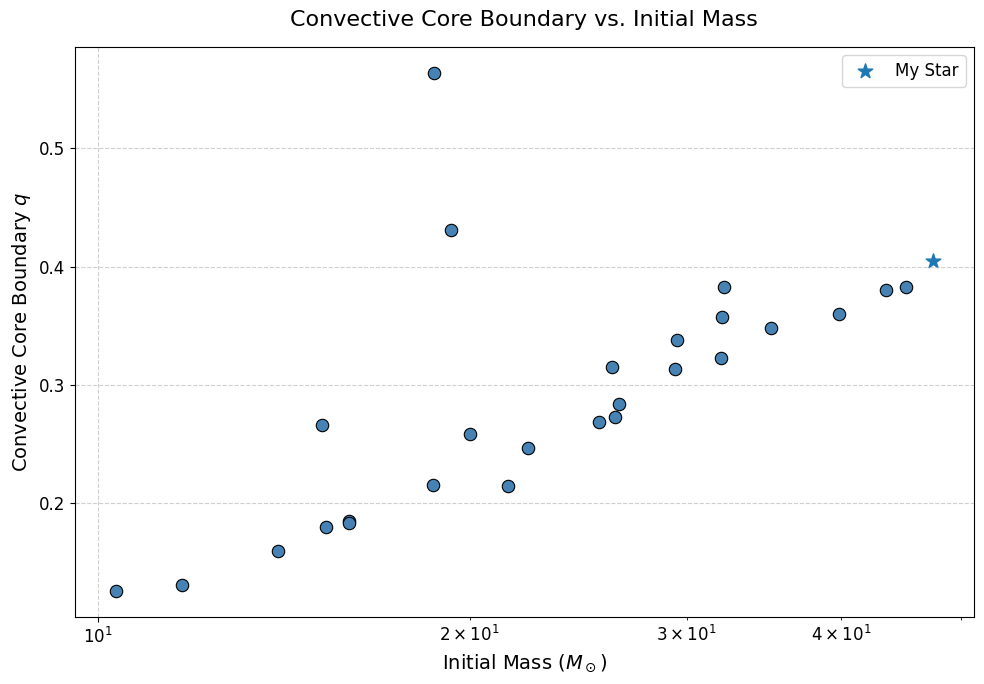

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Set a global font size for better readability
plt.rcParams.update({'font.size': 12})

df = pd.read_csv("ex22222.csv")

plt.figure(figsize=(10, 7))

plt.scatter(
    df["mass_in_Msun"],
    df["q_top_tams"],
    s=80, # Increased marker size for better visibility
    color='steelblue', # A more distinct color
    edgecolor='black', # Add edge color to markers
    linewidth=0.8 # Line width for marker edge
)

plt.scatter(
    47.504,
    0.405,
    s=120,
    marker='*',
    label='My Star'
)

plt.xlabel(r'Initial Mass ($M_\odot$)', fontsize=14)
plt.ylabel(r'Convective Core Boundary $q$', fontsize=14)
plt.title('Convective Core Boundary vs. Initial Mass', fontsize=16, pad=15) # Added a descriptive title

plt.xscale('log')

plt.grid(True, linestyle='--', alpha=0.6) # Made grid lines more visible
plt.legend(fontsize=12) # Increased legend font size
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

#### Fast Rotators

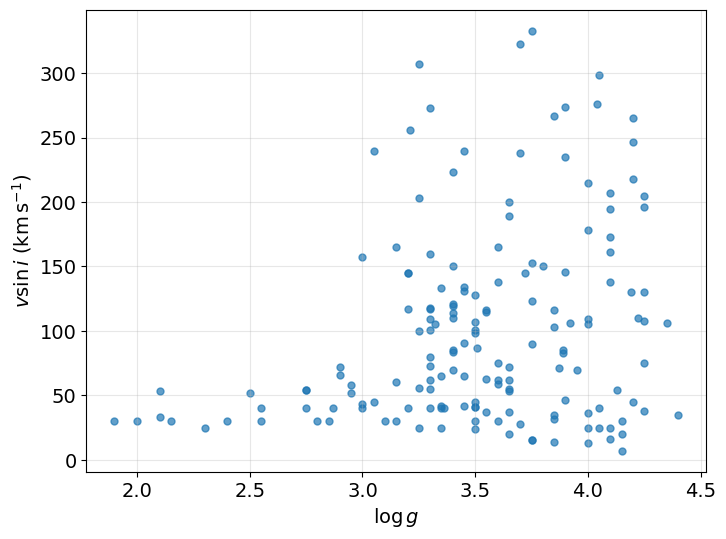

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

obs = pd.read_csv("stars (2).csv")

plt.figure(figsize=(8,6))

plt.scatter(
    obs["logg"],
    obs["vsini"],
    alpha=0.7,
    s=25
)

plt.xlabel(r'$\log g$')
plt.ylabel(r'$v\sin i\ {\rm (km\,s^{-1})}$')

plt.grid(alpha=0.3)

plt.show()

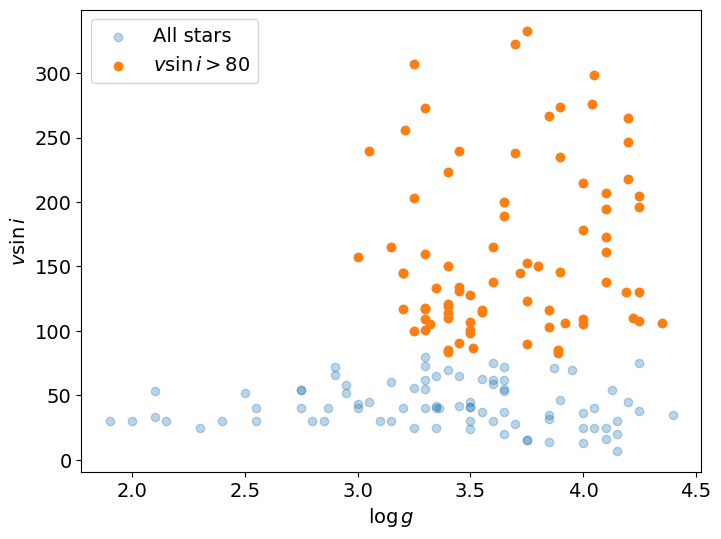

In [ ]:
fast = obs[obs["vsini"] > 80]

plt.figure(figsize=(8,6))

plt.scatter(
    obs["logg"],
    obs["vsini"],
    alpha=0.3,
    label="All stars"
)

plt.scatter(
    fast["logg"],
    fast["vsini"],
    label=r'$v\sin i > 80$'
)

plt.xlabel(r'$\log g$')
plt.ylabel(r'$v\sin i$')

plt.legend()

plt.show()

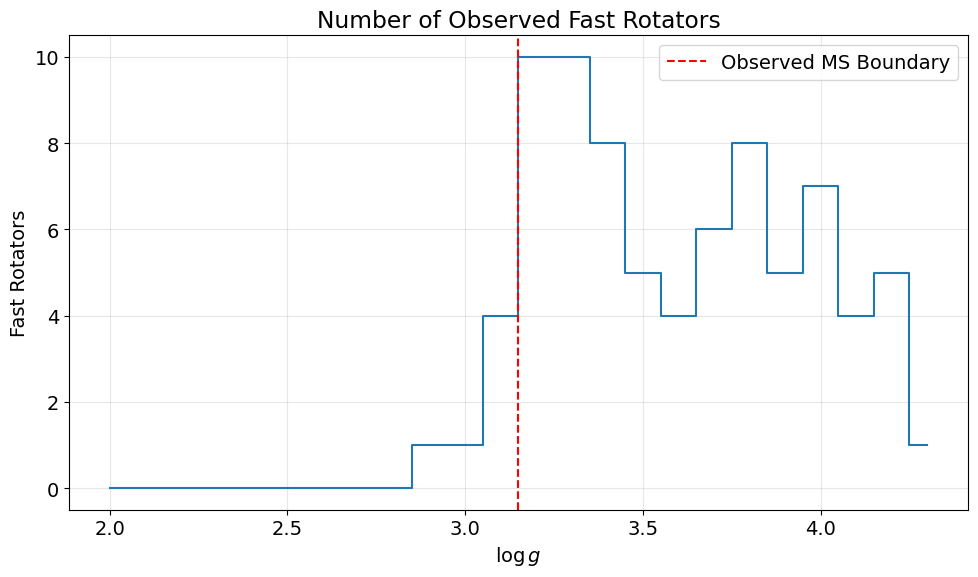

In [ ]:
import numpy as np

bins = np.arange(2.0,4.5,0.1)

counts=[]

for i in range(len(bins)-1):

    mask = (
        (fast["logg"]>=bins[i]) &
        (fast["logg"]<bins[i+1])
    )

    counts.append(mask.sum())

plt.figure(figsize=(10,6))

plt.step(
    bins[:-1],
    counts,
    where='mid'
)

plt.axvline(
    3.15,
    color='red',
    linestyle='--',
    label='Observed MS Boundary'
)

plt.xlabel(r'$\log g$')
plt.ylabel('Fast Rotators')

plt.grid(alpha=0.3)
plt.title('Number of Observed Fast Rotators')
plt.legend()
plt.tight_layout()
plt.show()